# Analysis of a Superstore dataset
### Dataset from Kaggle: https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting
<b>Questions to be answered:</b>
<ol>
    <li>Which category had the highest sales?</li>
    <li>Which state had the fewest customers?</li>
    <li>Which months performed best?</li>
    <li>Which customers had spent the most? (Who are the most valuable?)</li>
    <li>How are the sales distributed?</li>
</ol>

<b>Answers using SQL queries:</b>
<ol>
    <li>Which category had the highest sales?<br><br>
    <pre>SELECT
	SUM("Sales") AS sales,
	"Category" 
FROM superstore
GROUP BY "Category"
ORDER BY sales DESC;</pre><br>
    This query output the following table:<br><br>
    <table>
        <tr><th>sales</th><th>Category</th></tr>
        <tr><th>827457.2</th><th>Technology</th></tr>
        <tr><th>728657.94</th><th>Furniture</th></tr>
        <tr><th>705423.25</th><th>Office Supplies</th></tr>
    </table><br>
    Hence the category with the highest sales was Technology.</li><br>
    <li>Which state had the fewest customers?<br>
    <pre>SELECT
	COUNT(distinct "Customer ID") AS total_state,
	"State"
FROM superstore
GROUP BY "State" 
ORDER BY total_state ASC;</pre>
    This query output the following table (only the first two rows and final two are shown for conciseness):<br><br>
    <table>
        <tr><th>total_state</th><th>State</th></tr>
        <tr><th>1</th><th>Wyoming</th></tr>
        <tr><th>2</th><th>North Dakota</th></tr>
        <tr><th>409</th><th>New York</th></tr>
        <tr><th>570</th><th>California</th></tr>
    </table><br>
    Which says that the state with the least number of customers was Wyoming.</li><br>
    <li>Which months performed the best?<br>
    <pre>SELECT
	AVG("Sales") AS avg_sales,
	SUBSTRING("Order Date" FROM 4 FOR 2) AS month
FROM superstore
GROUP BY month
ORDER BY avg_sales DESC;</pre>
    This query output the following table (only the first two rows and final two are shown for conciseness):<br><br>
    <table>
        <tr><th>avg_sales</th><th>month</th></tr>
        <tr><th>290.5493936456302</th><th>03</th></tr>
        <tr><th>257.62740175483003</th><th>01</th></tr>
        <tr><th>207.43226817154994</th><th>04</th></tr>
        <tr><th>199.90274553427392</th><th>02</th></tr>
    </table><br>
    Thus, the months which performed the best were, on average, March and January.</li><br>
    <li>Which customers had spent the most? (Who are the most valuable?)<br>
    <pre>SELECT
	"Customer ID",
	"Customer Name",
	SUM("Sales") AS total_sales
FROM superstore
GROUP BY "Customer ID", "Customer Name"
ORDER BY total_sales DESC;</pre>
    This query output the following table (only the first four rows are shown for conciseness):<br><br>
    <table>
        <tr><th>Customer ID</th><th>Customer Name</th><th>total_sales</th></tr>
        <tr><th>SM-20320</th><th>Sean Miller</th><th>25043.053</th></tr>
        <tr><th>TC-20980</th><th>Tamara Chand</th><th>19052.217</th></tr>
        <tr><th>RB-19360</th><th>Raymond Buch</th><th>15117.339</th></tr>
        <tr><th>TA-21385</th><th>Tom Ashbrook</th><th>14595.621</th></tr>
    </table><br>
    Which shows the most valuable customers.</li>
</ol>

<b>Answers using Python</b>

Below, Python is used to analyse the sales, answering question 5, as well as plotting sales by category.

In [320]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np

## Data Overview

In [321]:
df = pd.read_csv("superstore.csv")
## print(df.to_string())
print(df.head(3).to_string(), "\n") # first 5 rows
print(df.tail(3).to_string()) # last 3 rows
sales = df["Sales"]
mean = sales.mean()
sd = math.sqrt(sales.var())
min, max = sales.min(), sales.max()
print("\n", min, max, mean, sd)

   Row ID        Order ID  Order Date   Ship Date     Ship Mode Customer ID    Customer Name    Segment        Country         City       State  Postal Code Region       Product ID         Category Sub-Category                                                 Product Name   Sales
0       1  CA-2017-152156  08/11/2017  11/11/2017  Second Class    CG-12520      Claire Gute   Consumer  United States    Henderson    Kentucky      42420.0  South  FUR-BO-10001798        Furniture    Bookcases                            Bush Somerset Collection Bookcase  261.96
1       2  CA-2017-152156  08/11/2017  11/11/2017  Second Class    CG-12520      Claire Gute   Consumer  United States    Henderson    Kentucky      42420.0  South  FUR-CH-10000454        Furniture       Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back  731.94
2       3  CA-2017-138688  12/06/2017  16/06/2017  Second Class    DV-13045  Darrin Van Huff  Corporate  United States  Los Angeles  California      90036.0   W

### Sales
<ul>
    <li>Mean: $230.77</li>
    <li>Range: $0.44–$22638.48</li>
    <li>Standard deviation: $628.65</li>
</ul>

The large range, low mean and (relatively) small standard deviation suggest that the distribution of sales is positively skewed. We can check this by finding the median.

In [322]:
print(sales.median())

54.489999999999995


The median is $54.49. This is significantly less than the mean which confirms the positive skew. We can plot the frequency densities in the inter-quartile range to show this.

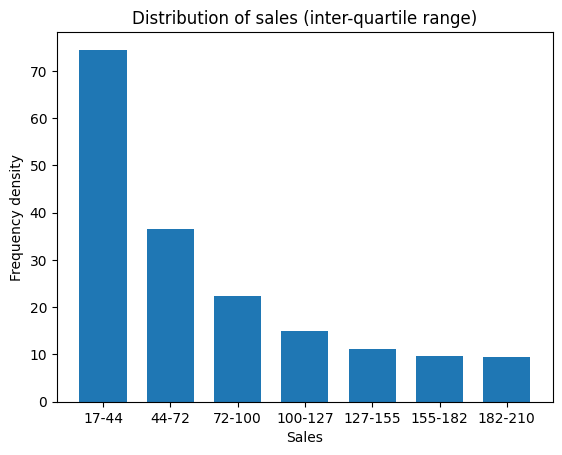

In [323]:
values = sales.to_list()
Q1 = np.quantile(values, 0.25)
Q3 = np.quantile(values, 0.75)
width = (Q3 - Q1)/n
n = 7 # number of intervals
counts = [0 for i in range(n)]
bounds = [int(Q1 + i * width) for i in range(n + 1)]
intervals = [str(bounds[i]) + "-" + str(bounds[i + 1]) for i in range(n)]
for i in range(len(values)):
    for j in range(n):
        if values[i] >= bounds[j] and values[i] < bounds[j + 1]:
            counts[j] += 1
for i in range(n):
    counts[i] *= 1/width
plt.bar(intervals, counts, width = 0.7)
plt.xlabel("Sales")
plt.ylabel("Frequency density")
plt.title("Distribution of sales (inter-quartile range)")
plt.savefig("sales_distribution.png")
plt.show()

<Figure size 640x480 with 0 Axes>

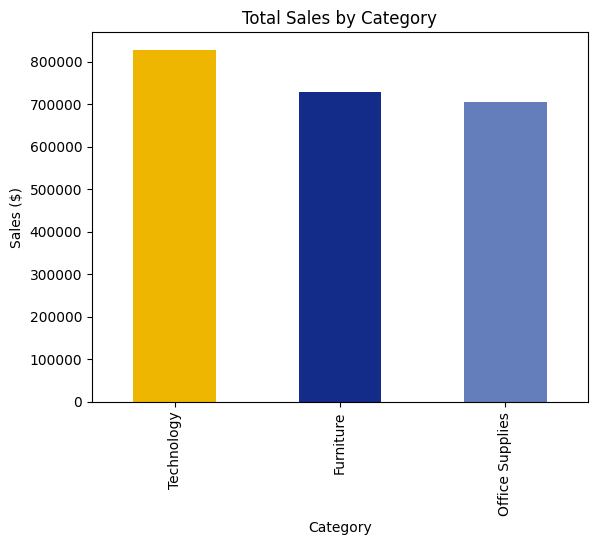

In [324]:
sales_by_category = df.groupby("Category")["Sales"].sum().reset_index().sort_values("Sales", ascending = False)
plt.figure()
sales_by_category.plot(kind = "bar", x = "Category", y = "Sales", xlabel = "Category", ylabel = "Sales ($)", legend = False, title = "Total Sales by Category", 
                       color = ["#EEB600", "#132C89", "#647EBC"])
plt.savefig("sales_by_category.png", bbox_inches = "tight")
plt.show()